In [1]:
pip install matplotlib pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

Creando tablas Gold...

ANÁLISIS DE BIODIVERSIDAD - RESPUESTAS

1. HÁBITATS CON MAYOR RIQUEZA TOTAL DE ESPECIES:
                     HABITAT  total_richness  years_covered  avg_richness_per_year
            Coastal habitats         40176.0             52             772.615385
Estuarine and coastal waters         39840.0             50             796.800000
                 Tidal flats         22415.0             78             287.371795
                       Mixed         19965.0             54             369.722222
              Oceanic waters         18051.0             97             186.092784

2. BIODIVERSIDAD POR REINO (REALM):
      REALM  total_richness  avg_richness_per_year  years_covered
     Marine        207289.0            1771.700855            117
Terrestrial        185813.0            1561.453782            119
 Freshwater         45296.0             718.984127             63

3. ESPECIE MÁS FRECUENTE (mayor número de registros):
   Especie: 'pseudacris crucifer'

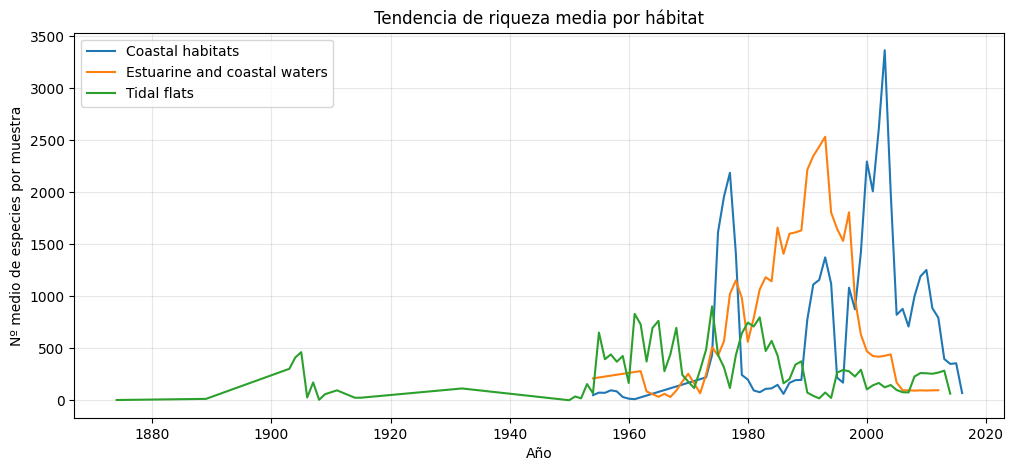

   Gráfico guardado en P:/proyecto_1/datos/gold_output\richness_trend_by_habitat.png

ANÁLISIS DE ESTACIONALIDAD DE LA ABUNDANCIA
Estacionalidad de la abundancia promedio:
    month_num  mean_abundance    n_obs
0           1       79.985984   434174
1           2      104.638554   371762
2           3      122.474863   515433
3           4      126.270457   691122
4           5      107.398038   989285
5           6       87.208547  1320901
6           7      259.885289  1607041
7           8      131.415004   947788
8           9      136.665229   914561
9          10      139.027797   817408
10         11      137.166714   428766
11         12      152.606663   206052


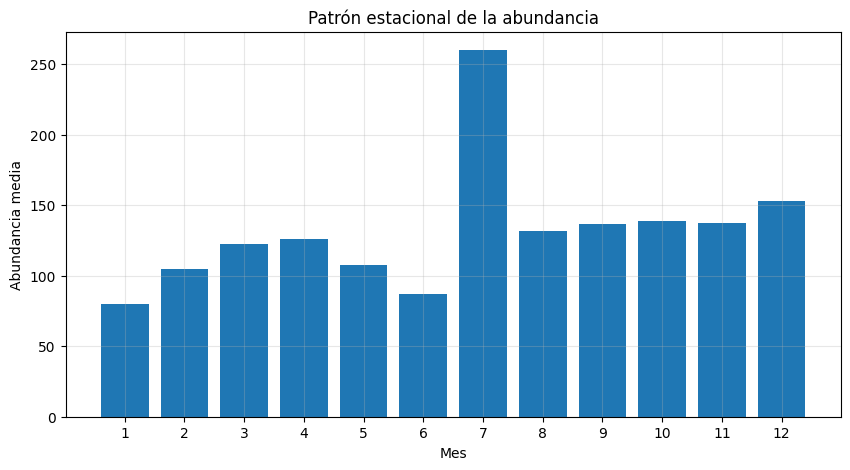

Gráfico guardado en: P:/proyecto_1/datos/gold_output\seasonal_pattern.png

ANÁLISIS DE ACUMULACIÓN DE ESPECIES POR ESTUDIO
Estudio seleccionado (más datos): 195


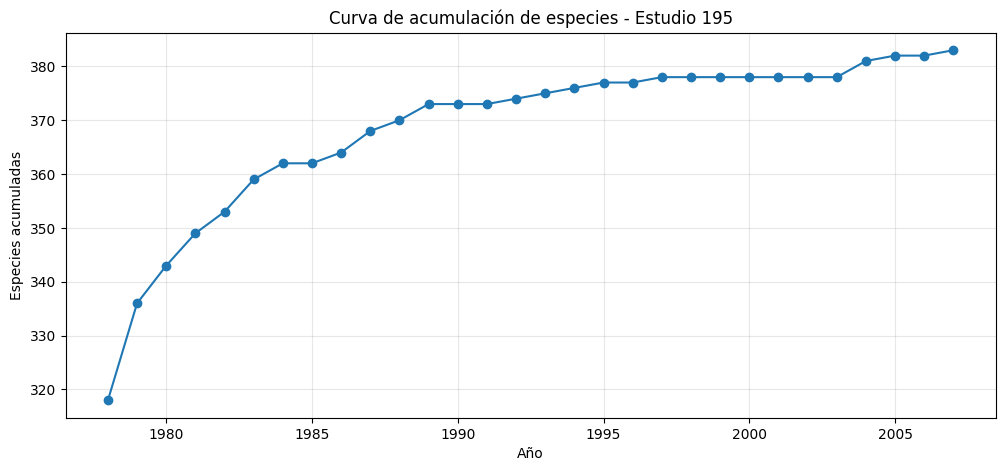

Gráfico guardado en P:/proyecto_1/datos/gold_output\accumulation_curve_study_195.png

Exportando tablas Gold a Parquet...
Tablas guardadas en P:/proyecto_1/datos/gold_output


In [7]:
# Capa Gold - Análisis de biodiversidad BioTIME (local)
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import os

# ========== CONFIGURACIÓN DE RUTAS (nuevas ubicaciones) ==========
silver_parquet = 'P:/proyecto_1/datos/silver_output/silver_biotime_cleaned.parquet'
gold_output_dir = 'P:/proyecto_1/datos/gold_output'
os.makedirs(gold_output_dir, exist_ok=True)

# Conectar a DuckDB
conn = duckdb.connect()
conn.execute("CREATE SCHEMA IF NOT EXISTS gold;")

if not os.path.exists(silver_parquet):
    raise FileNotFoundError(f"No se encontró {silver_parquet}. Ejecuta Silver primero.")

# ========== CREAR TABLAS GOLD (riqueza por estudio, hábitat, reino) ==========
print("Creando tablas Gold...")
conn.execute(f"""
CREATE OR REPLACE TABLE gold.species_richness_by_study AS
SELECT STUDY_ID, YEAR,
       COUNT(DISTINCT species_name) AS unique_species_count,
       COUNT(*) AS total_observations
FROM read_parquet('{silver_parquet}')
WHERE species_name IS NOT NULL AND YEAR IS NOT NULL
GROUP BY STUDY_ID, YEAR;
""")

conn.execute(f"""
CREATE OR REPLACE TABLE gold.species_richness_by_habitat AS
SELECT HABITAT, YEAR,
       COUNT(DISTINCT species_name) AS unique_species_count,
       COUNT(*) AS total_observations
FROM read_parquet('{silver_parquet}')
WHERE HABITAT IS NOT NULL AND YEAR IS NOT NULL
GROUP BY HABITAT, YEAR;
""")

conn.execute(f"""
CREATE OR REPLACE TABLE gold.species_richness_by_realm AS
SELECT REALM, YEAR,
       COUNT(DISTINCT species_name) AS unique_species_count,
       COUNT(*) AS total_observations
FROM read_parquet('{silver_parquet}')
WHERE REALM IS NOT NULL AND YEAR IS NOT NULL
GROUP BY REALM, YEAR;
""")

conn.execute(f"""
CREATE OR REPLACE TABLE gold.top_species_by_occurrence AS
SELECT species_name,
       COUNT(*) AS occurrence_count,
       AVG(ABUNDANCE) AS avg_abundance,
       SUM(ABUNDANCE) AS total_abundance
FROM read_parquet('{silver_parquet}')
WHERE ABUNDANCE > 0 AND species_name IS NOT NULL
GROUP BY species_name
ORDER BY occurrence_count DESC
LIMIT 10;
""")

# ========== ANÁLISIS Y RESPUESTAS ==========
print("\n" + "="*70)
print("ANÁLISIS DE BIODIVERSIDAD - RESPUESTAS")
print("="*70)

# A. Hábitats con mayor riqueza acumulada
print("\n1. HÁBITATS CON MAYOR RIQUEZA TOTAL DE ESPECIES:")
df_hab = conn.execute("""
    SELECT HABITAT,
           SUM(unique_species_count) AS total_richness,
           COUNT(DISTINCT YEAR) AS years_covered,
           AVG(unique_species_count) AS avg_richness_per_year
    FROM gold.species_richness_by_habitat
    GROUP BY HABITAT
    ORDER BY total_richness DESC
    LIMIT 5
""").fetchdf()
print(df_hab.to_string(index=False))

# B. Comparación entre reinos (REALM)
print("\n2. BIODIVERSIDAD POR REINO (REALM):")
df_realm = conn.execute("""
    SELECT REALM,
           SUM(unique_species_count) AS total_richness,
           AVG(unique_species_count) AS avg_richness_per_year,
           COUNT(DISTINCT YEAR) AS years_covered
    FROM gold.species_richness_by_realm
    WHERE REALM IS NOT NULL
    GROUP BY REALM
    ORDER BY total_richness DESC
""").fetchdf()
print(df_realm.to_string(index=False))

# C. Especie más frecuente (por ocurrencias) y su tendencia
print("\n3. ESPECIE MÁS FRECUENTE (mayor número de registros):")
top_spp = conn.execute("SELECT species_name, occurrence_count, avg_abundance FROM gold.top_species_by_occurrence LIMIT 1").fetchdf()
if not top_spp.empty:
    sp_name = top_spp.iloc[0,0]
    print(f"   Especie: '{sp_name}'")
    print(f"   Nº de ocurrencias: {top_spp.iloc[0,1]:,}")
    print(f"   Abundancia media: {top_spp.iloc[0,2]:.2f}")

    df_trend = conn.execute(f"""
        SELECT YEAR,
               AVG(ABUNDANCE) AS mean_abundance,
               SUM(ABUNDANCE) AS total_abundance,
               COUNT(*) AS occurrences
        FROM read_parquet('{silver_parquet}')
        WHERE species_name = '{sp_name}' AND ABUNDANCE > 0
        GROUP BY YEAR
        ORDER BY YEAR
    """).fetchdf()
    if not df_trend.empty:
        print("\n   Tendencia anual (primeros y últimos 5 años):")
        print(df_trend.head(5).to_string(index=False))
        print("   ...")
        print(df_trend.tail(5).to_string(index=False))

# D. Evolución temporal de la riqueza por hábitat (top 3 hábitats)
print("\n4. EVOLUCIÓN DE LA RIQUEZA EN LOS 3 HÁBITATS CON MAYOR RIQUEZA TOTAL:")
top_habitats = conn.execute("""
    SELECT HABITAT FROM gold.species_richness_by_habitat
    GROUP BY HABITAT
    ORDER BY SUM(unique_species_count) DESC
    LIMIT 3
""").fetchdf()['HABITAT'].tolist()

if top_habitats:
    plt.figure(figsize=(12,5))
    for hab in top_habitats:
        df_hab_trend = conn.execute(f"""
            SELECT YEAR, AVG(unique_species_count) AS avg_richness
            FROM gold.species_richness_by_habitat
            WHERE HABITAT = '{hab}'
            GROUP BY YEAR
            ORDER BY YEAR
        """).fetchdf()
        plt.plot(df_hab_trend['YEAR'], df_hab_trend['avg_richness'], label=hab)
    plt.title('Tendencia de riqueza media por hábitat')
    plt.xlabel('Año')
    plt.ylabel('Nº medio de especies por muestra')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plot_path = os.path.join(gold_output_dir, 'richness_trend_by_habitat.png')
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"   Gráfico guardado en {plot_path}")

# ========== ANÁLISIS DE ESTACIONALIDAD (meses) ==========
print("\n" + "="*70)
print("ANÁLISIS DE ESTACIONALIDAD DE LA ABUNDANCIA")
print("="*70)

# Verificar si hay valores no nulos en MONTH
has_month = conn.execute(f"""
    SELECT COUNT(*) FROM read_parquet('{silver_parquet}')
    WHERE MONTH IS NOT NULL AND MONTH != ''
""").fetchone()[0]

if has_month > 0:
    query = f"""
    SELECT
        CASE
            WHEN MONTH IN ('1','01','January','Jan') THEN 1
            WHEN MONTH IN ('2','02','February','Feb') THEN 2
            WHEN MONTH IN ('3','03','March','Mar') THEN 3
            WHEN MONTH IN ('4','04','April','Apr') THEN 4
            WHEN MONTH IN ('5','05','May') THEN 5
            WHEN MONTH IN ('6','06','June','Jun') THEN 6
            WHEN MONTH IN ('7','07','July','Jul') THEN 7
            WHEN MONTH IN ('8','08','August','Aug') THEN 8
            WHEN MONTH IN ('9','09','September','Sep') THEN 9
            WHEN MONTH IN ('10','October','Oct') THEN 10
            WHEN MONTH IN ('11','November','Nov') THEN 11
            WHEN MONTH IN ('12','December','Dec') THEN 12
            ELSE NULL
        END AS month_num,
        AVG(ABUNDANCE) AS mean_abundance,
        COUNT(*) AS n_obs
    FROM read_parquet('{silver_parquet}')
    WHERE ABUNDANCE > 0 AND MONTH IS NOT NULL AND MONTH != ''
    GROUP BY month_num
    HAVING month_num IS NOT NULL
    ORDER BY month_num;
    """
    df_season = conn.execute(query).fetchdf()
    print("Estacionalidad de la abundancia promedio:")
    print(df_season)

    plt.figure(figsize=(10,5))
    plt.bar(df_season['month_num'], df_season['mean_abundance'])
    plt.xlabel('Mes')
    plt.ylabel('Abundancia media')
    plt.title('Patrón estacional de la abundancia')
    plt.xticks(range(1,13))
    plt.grid(True, alpha=0.3)
    season_plot_path = os.path.join(gold_output_dir, 'seasonal_pattern.png')
    plt.savefig(season_plot_path, dpi=150)
    plt.show()
    print(f"Gráfico guardado en: {season_plot_path}")
else:
    print("No hay datos de mes en este conjunto.")

# ========== ANÁLISIS ADICIONAL: CURVA DE ACUMULACIÓN POR ESTUDIO ==========
print("\n" + "="*70)
print("ANÁLISIS DE ACUMULACIÓN DE ESPECIES POR ESTUDIO")
print("="*70)

# Seleccionar el STUDY_ID con más registros
study_id = conn.execute(f"""
    SELECT STUDY_ID, COUNT(*) as n
    FROM read_parquet('{silver_parquet}')
    GROUP BY STUDY_ID
    ORDER BY n DESC
    LIMIT 1
""").fetchone()[0]
print(f"Estudio seleccionado (más datos): {study_id}")

# Curva de acumulación
query = f"""
WITH ordered_data AS (
    SELECT
        YEAR,
        species_name,
        ROW_NUMBER() OVER (ORDER BY YEAR, ID_ALL_RAW_DATA) AS seq
    FROM read_parquet('{silver_parquet}')
    WHERE STUDY_ID = {study_id} AND species_name IS NOT NULL
),
cumulative AS (
    SELECT
        seq,
        YEAR,
        species_name,
        COUNT(DISTINCT species_name) OVER (ORDER BY seq) AS cum_species
    FROM ordered_data
)
SELECT YEAR, MAX(cum_species) AS accumulated_richness
FROM cumulative
GROUP BY YEAR
ORDER BY YEAR;
"""
df_acc = conn.execute(query).fetchdf()

if not df_acc.empty:
    plt.figure(figsize=(12,5))
    plt.plot(df_acc['YEAR'], df_acc['accumulated_richness'], marker='o', linestyle='-')
    plt.xlabel('Año')
    plt.ylabel('Especies acumuladas')
    plt.title(f'Curva de acumulación de especies - Estudio {study_id}')
    plt.grid(True, alpha=0.3)
    acc_plot_path = os.path.join(gold_output_dir, f'accumulation_curve_study_{study_id}.png')
    plt.savefig(acc_plot_path, dpi=150)
    plt.show()
    print(f"Gráfico guardado en {acc_plot_path}")
else:
    print("No hay datos suficientes para generar la curva de acumulación.")

# ========== EXPORTAR TABLAS GOLD A PARQUET ==========
print("\nExportando tablas Gold a Parquet...")
conn.execute(f"COPY gold.species_richness_by_study TO '{gold_output_dir}/gold_species_richness_by_study.parquet' (FORMAT PARQUET);")
conn.execute(f"COPY gold.species_richness_by_habitat TO '{gold_output_dir}/gold_species_richness_by_habitat.parquet' (FORMAT PARQUET);")
conn.execute(f"COPY gold.species_richness_by_realm TO '{gold_output_dir}/gold_species_richness_by_realm.parquet' (FORMAT PARQUET);")
conn.execute(f"COPY gold.top_species_by_occurrence TO '{gold_output_dir}/gold_top_species_by_occurrence.parquet' (FORMAT PARQUET);")
print(f"Tablas guardadas en {gold_output_dir}")

# Cerrar conexión
conn.close()
